In [1]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

nltk.download('vader_lexicon')

df = pd.read_csv("spotify_millsongdata.csv")

vds = SentimentIntensityAnalyzer()

records = []
for _, row in df.iterrows():
    scores = vds.polarity_scores(str(row["text"]))
    records.append({
        "Song":     row["song"],
        "Artist":   row["artist"],
        "Compound": scores["compound"],
        "Negitive":      scores["neg"],
        "Neutral":      scores["neu"],
        "Positive":      scores["pos"],
    })

sentiment_df = pd.DataFrame(records)

sentiment_df.to_csv("spotify_sentiment_scores.csv", index=False)




[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/shayna/nltk_data...


In [4]:
sentiment_df.dropna(subset=['Compound', 'Negitive', 'Neutral', 'Positive'], inplace=True)
sentiment_df.drop_duplicates(subset=['Song', 'Artist'], inplace=True)

sentiment_df.to_csv("spotify_sentiment_scores.csv", index=False)

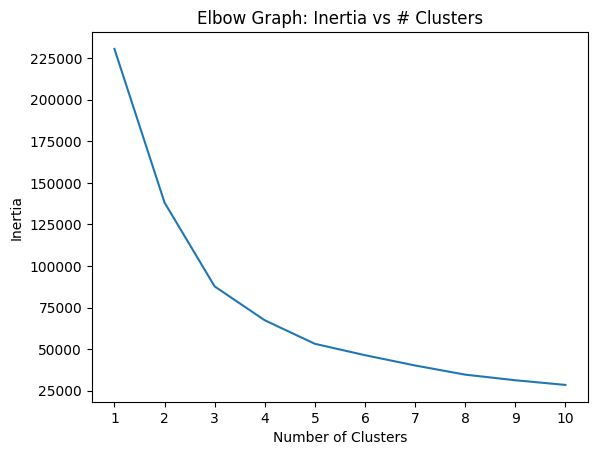

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

def plot_elbow_curve(
    df: pd.DataFrame,
    feature_cols: list[str],
    num_iterations=10,
    num_max_iter=300
):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[feature_cols])

    sse = []
    for k in range(1, 11):
        km = KMeans(
            n_clusters=k,
            n_init=num_iterations,
            max_iter=num_max_iter,
            random_state=42
        )
        km.fit(X)
        sse.append(km.inertia_)

    plt.plot(range(1, 11), sse)
    plt.xticks(range(1, 11))
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Graph: Inertia vs # Clusters')
    plt.show()

plot_elbow_curve(
    sentiment_df,
    feature_cols=["Compound","Negitive","Neutral","Positive"]
)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_cluster=3, random_state=42)
#sentiment_df = kmeans.fit_predict(X)